**Disease Prediction System**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("disease_prediction_healthcare_dataset.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease
0,P100001,64.0,Female,"abdominal pain, nausea, vomiting",141.0,NaN,212.0,NaN,Gastroenteritis
1,P100002,33.0,Male,"body ache, fever, fatigue",131.0,92.0,230.0,Seasonal flu,Flu
2,P100003,18.0,Male,NaN,104.0,91.0,158.0,NaN,Healthy
3,P100004,18.0,Female,"dizziness, nausea, sensitivity to light",112.0,85.0,206.0,Family history of migraine,Migraine
4,P100005,70.0,Male,"frequent urination, blurred vision, increased ...",157.0,188.0,184.0,Diabetes,Diabetes


In [4]:
df.shape

(3020, 9)

In [5]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Symptoms', 'Blood_Pressure',
       'Sugar_Level', 'Cholesterol', 'Medical_History', 'Disease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       3020 non-null   object 
 1   Age              2990 non-null   float64
 2   Gender           3020 non-null   object 
 3   Symptoms         2515 non-null   object 
 4   Blood_Pressure   2989 non-null   float64
 5   Sugar_Level      2990 non-null   float64
 6   Cholesterol      2989 non-null   float64
 7   Medical_History  1709 non-null   object 
 8   Disease          3020 non-null   object 
dtypes: float64(4), object(5)
memory usage: 212.5+ KB


In [7]:
df.describe()

,Age,Blood_Pressure,Sugar_Level,Cholesterol
count,2990.000000,2989.000000,2990.000000,2989.000000
mean,46.472241,129.392774,114.063211,209.070927
std,15.975885,18.880843,34.206980,35.817658
min,18.000000,90.000000,65.000000,120.000000
25%,35.000000,116.000000,90.000000,183.000000
50%,46.000000,129.000000,108.000000,206.000000
75%,57.000000,142.000000,131.000000,235.000000
max,85.000000,195.000000,232.000000,318.000000


In [8]:
df.describe(include='object')

,Patient_ID,Gender,Symptoms,Medical_History,Disease
count,3020,3020,2515,1709,3020
unique,3000,2,528,14,8
top,P101412,Male,"dizziness, headache",Seasonal flu,Flu
freq,2,1545,48,250,505


In [9]:
df["Disease"].unique()

array(['Gastroenteritis', 'Flu', 'Healthy', 'Migraine', 'Diabetes',
       'Heart Disease', 'Pneumonia', 'Hypertension'], dtype=object)

In [10]:
df["Disease"].nunique()

8

In [11]:
df["Disease"].value_counts()

Disease
Flu                505
Healthy            466
Diabetes           459
Hypertension       435
Heart Disease      335
Pneumonia          294
Migraine           276
Gastroenteritis    250
Name: count, dtype: int64

In [12]:
df["Disease"].value_counts(normalize=True) * 100

Disease
Flu                16.721854
Healthy            15.430464
Diabetes           15.198675
Hypertension       14.403974
Heart Disease      11.092715
Pneumonia           9.735099
Migraine            9.139073
Gastroenteritis     8.278146
Name: proportion, dtype: float64

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

Age                  30
Symptoms            505
Blood_Pressure       31
Sugar_Level          30
Cholesterol          31
Medical_History    1311
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(1938)

In [15]:
df.isnull().sum()

Patient_ID            0
Age                  30
Gender                0
Symptoms            505
Blood_Pressure       31
Sugar_Level          30
Cholesterol          31
Medical_History    1311
Disease               0
dtype: int64

In [16]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

Patient_ID          0.000000
Age                 0.993377
Gender              0.000000
Symptoms           16.721854
Blood_Pressure      1.026490
Sugar_Level         0.993377
Cholesterol         1.026490
Medical_History    43.410596
Disease             0.000000
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(20)

In [18]:
df[df.duplicated()]

,Patient_ID,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease
3000,P101802,39.0,Female,"chest pain, cough, shortness of breath",NaN,65.0,198.0,NaN,Pneumonia
3001,P101191,52.0,Male,"body ache, sore throat, cough, fever",111.0,108.0,142.0,Seasonal flu,Flu
3002,P101818,61.0,Male,"cough, fatigue, sore throat",134.0,115.0,204.0,Seasonal flu,Flu
3003,P100252,58.0,Female,NaN,90.0,88.0,205.0,NaN,Healthy
3004,P102506,51.0,Male,"blurred vision, frequent urination, increased ...",120.0,220.0,193.0,Family history of diabetes,Diabetes
3005,P101118,61.0,Male,"nausea, abdominal pain, vomiting, fever",121.0,97.0,199.0,Gastritis,Gastroenteritis
3006,P101412,36.0,Male,NaN,104.0,65.0,167.0,NaN,Healthy
3007,P102114,61.0,Female,"fever, cough, shortness of breath, chest pain",129.0,68.0,174.0,Previous respiratory infection,Pneumonia
3008,P100409,59.0,Female,"fatigue, blurred vision",130.0,156.0,243.0,NaN,Diabetes
3009,P102580,20.0,Male,NaN,124.0,69.0,163.0,NaN,Healthy


In [21]:
df["Patient_ID"].duplicated().sum()

np.int64(20)

In [22]:
df = df.drop_duplicates()

In [23]:
df.shape

(3000, 9)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

Patient_ID            0
Age                  30
Gender                0
Symptoms            499
Blood_Pressure       30
Sugar_Level          30
Cholesterol          30
Medical_History    1302
Disease               0
dtype: int64

In [26]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Blood_Pressure"] = df["Blood_Pressure"].fillna(df["Blood_Pressure"].median())
df["Sugar_Level"] = df["Sugar_Level"].fillna(df["Sugar_Level"].median())
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

In [27]:
df["Symptoms"] = df["Symptoms"].fillna("Unknown")
df["Medical_History"] = df["Medical_History"].fillna("Unknown")

In [28]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
Symptoms           0
Blood_Pressure     0
Sugar_Level        0
Cholesterol        0
Medical_History    0
Disease            0
dtype: int64

In [29]:
df.shape

(3000, 9)

In [30]:
df["Disease"].value_counts()

Disease
Flu                502
Healthy            460
Diabetes           455
Hypertension       435
Heart Disease      335
Pneumonia          290
Migraine           275
Gastroenteritis    248
Name: count, dtype: int64

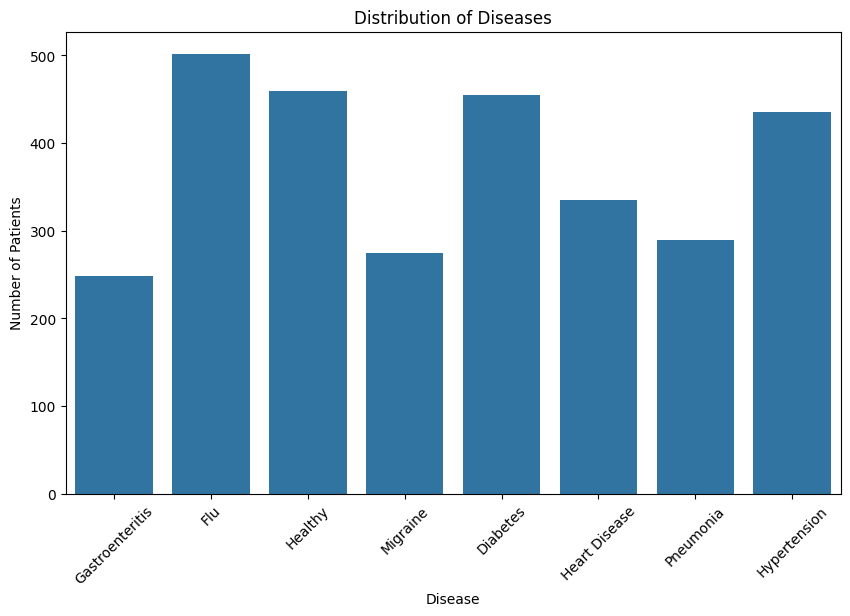

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Disease")

plt.title("Distribution of Diseases")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

In [32]:
df["Gender"].value_counts()

Gender
Male      1534
Female    1466
Name: count, dtype: int64

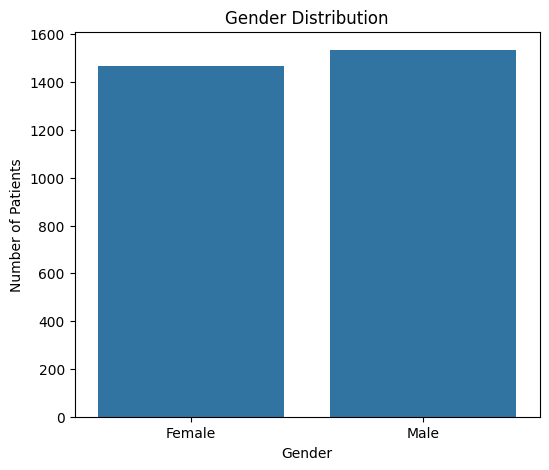

In [33]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

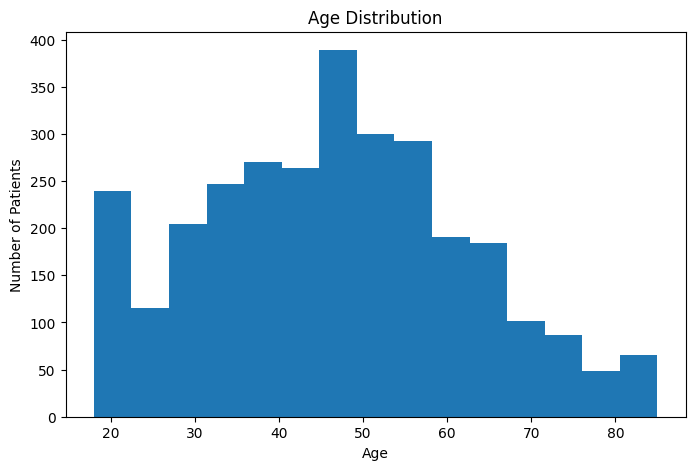

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

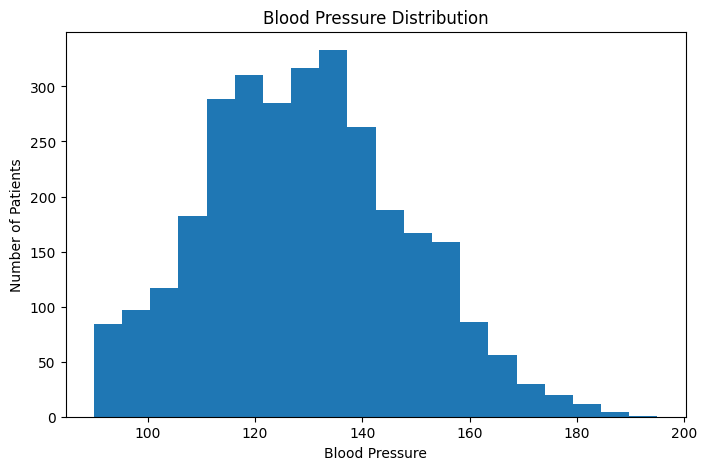

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(df["Blood_Pressure"], bins=20)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")

plt.show()

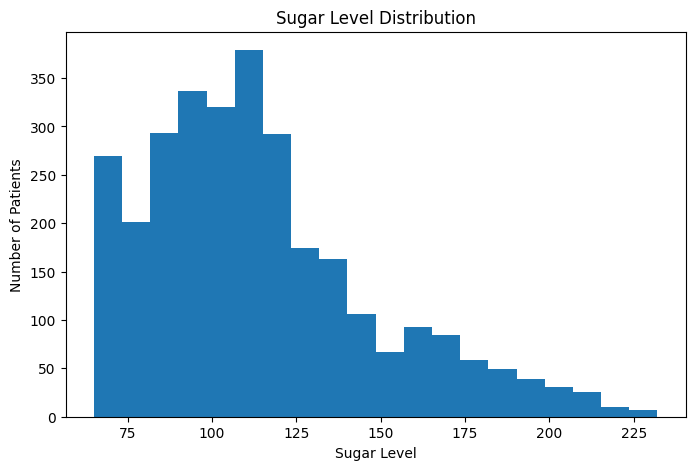

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sugar_Level"], bins=20)

plt.title("Sugar Level Distribution")
plt.xlabel("Sugar Level")
plt.ylabel("Number of Patients")

plt.show()

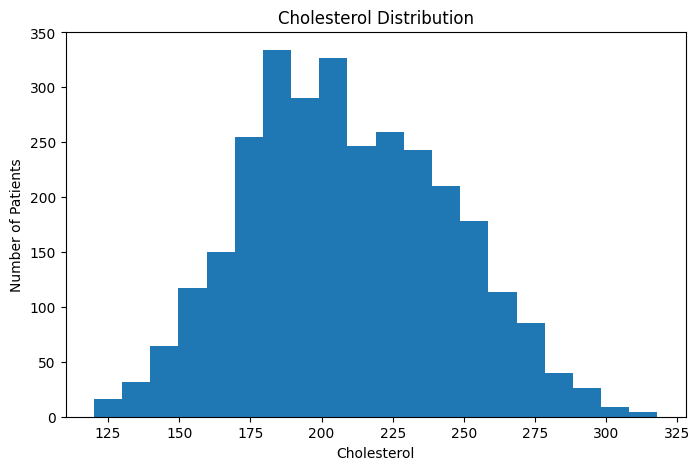

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(df["Cholesterol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

In [38]:
pd.crosstab(df["Disease"], df["Gender"])

Gender,Female,Male
Disease,,
Diabetes,222,233
Flu,253,249
Gastroenteritis,122,126
Healthy,219,241
Heart Disease,168,167
Hypertension,213,222
Migraine,138,137
Pneumonia,131,159


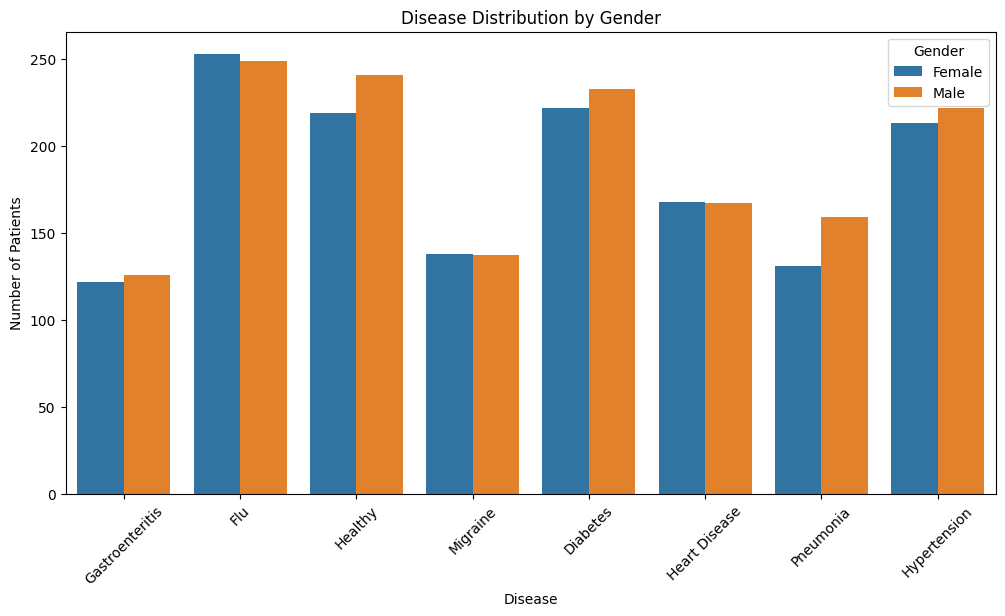

In [39]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="Disease", hue="Gender")

plt.title("Disease Distribution by Gender")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

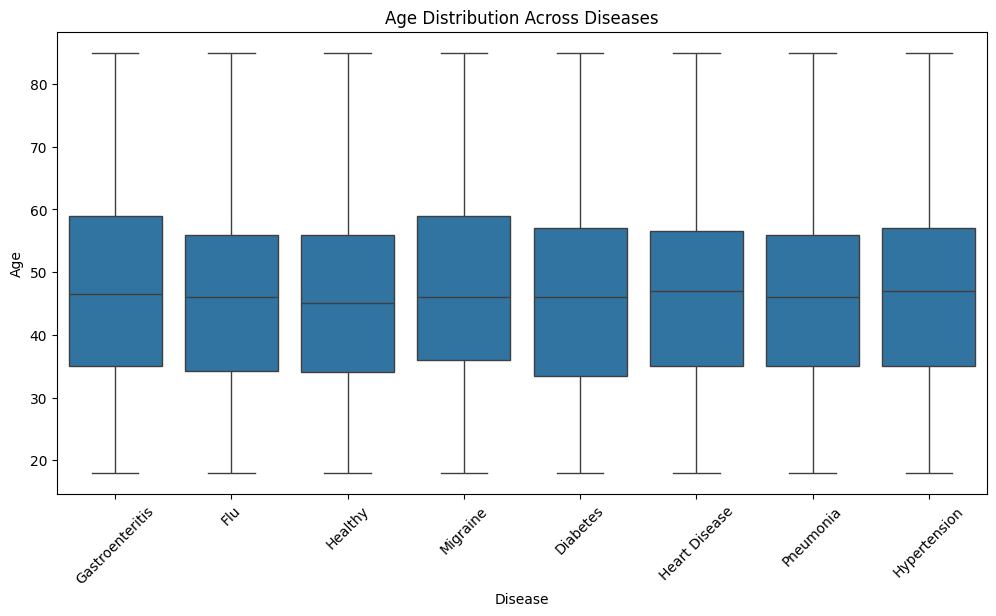

In [40]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Disease", y="Age")

plt.title("Age Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.show()

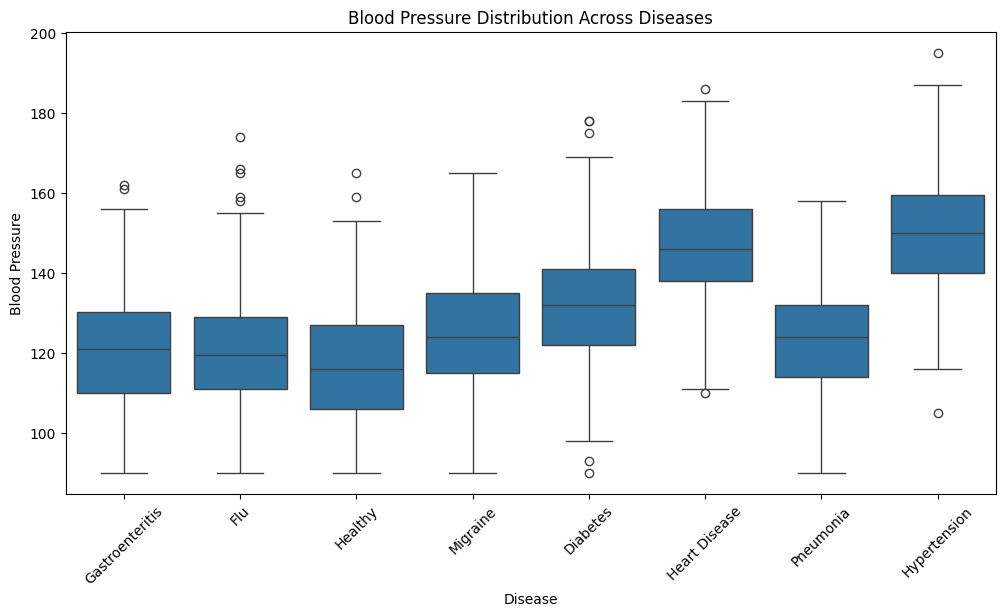

In [41]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Disease", y="Blood_Pressure")

plt.title("Blood Pressure Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Blood Pressure")
plt.xticks(rotation=45)

plt.show()

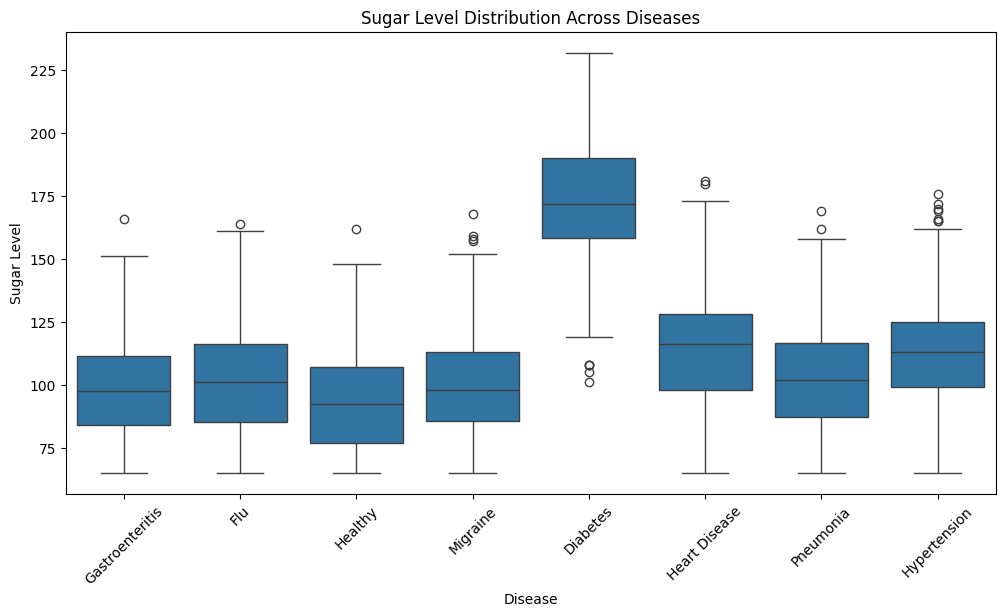

In [42]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Disease", y="Sugar_Level")

plt.title("Sugar Level Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Sugar Level")
plt.xticks(rotation=45)

plt.show()

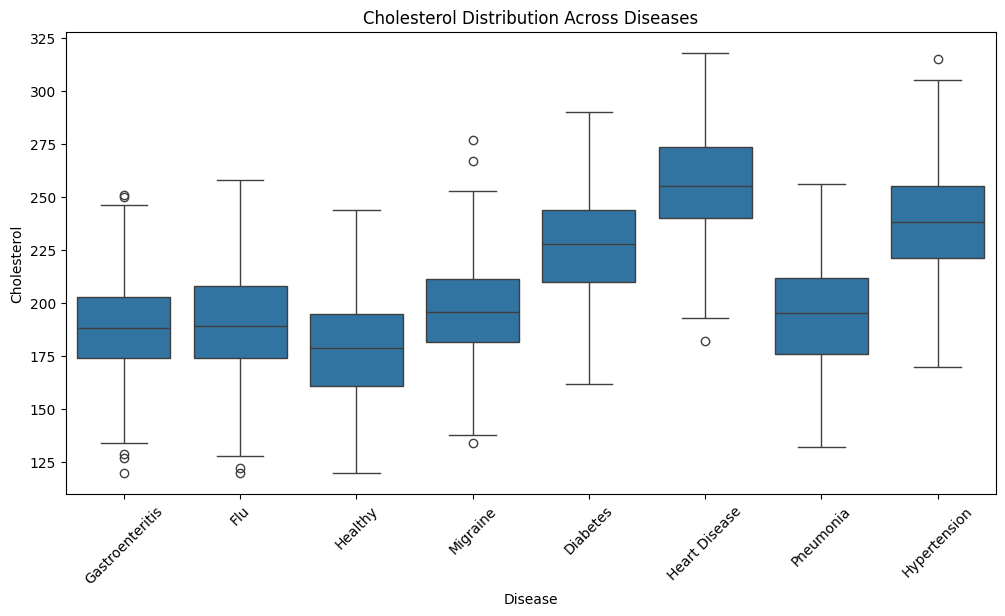

In [43]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Disease", y="Cholesterol")

plt.title("Cholesterol Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Cholesterol")
plt.xticks(rotation=45)

plt.show()

In [44]:
df[["Age", "Blood_Pressure", "Sugar_Level", "Cholesterol"]].corr()

,Age,Blood_Pressure,Sugar_Level,Cholesterol
Age,1.000000,0.171902,0.114001,0.091776
Blood_Pressure,0.171902,1.000000,0.177712,0.488167
Sugar_Level,0.114001,0.177712,1.000000,0.300231
Cholesterol,0.091776,0.488167,0.300231,1.000000


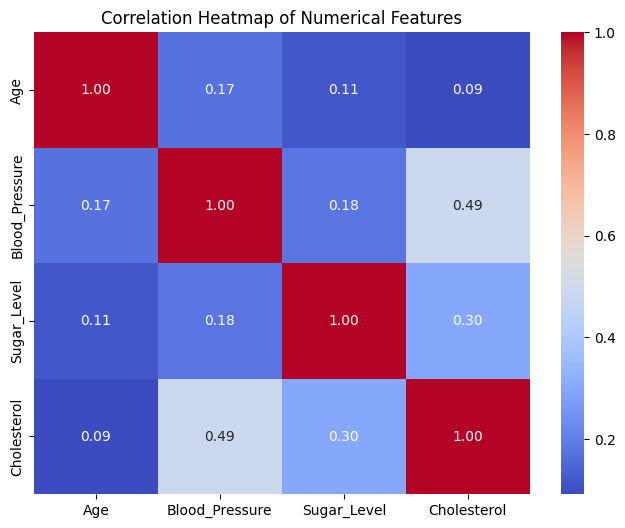

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["Age", "Blood_Pressure", "Sugar_Level", "Cholesterol"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [46]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

In [47]:
find_outliers("Age")

Column: Age
Q1: 35.0
Q3: 57.0
IQR: 22.0
Lower Bound: 2.0
Upper Bound: 90.0
Number of Outliers: 0


In [48]:
find_outliers("Blood_Pressure")

Column: Blood_Pressure
Q1: 116.0
Q3: 142.0
IQR: 26.0
Lower Bound: 77.0
Upper Bound: 181.0
Number of Outliers: 14


In [49]:
find_outliers("Sugar_Level")

Column: Sugar_Level
Q1: 90.0
Q3: 130.25
IQR: 40.25
Lower Bound: 29.625
Upper Bound: 190.625
Number of Outliers: 113


In [50]:
find_outliers("Cholesterol")

Column: Cholesterol
Q1: 183.0
Q3: 235.0
IQR: 52.0
Lower Bound: 105.0
Upper Bound: 313.0
Number of Outliers: 4


In [51]:
numerical_columns = ["Age", "Blood_Pressure", "Sugar_Level", "Cholesterol"]

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df[column] < lower_bound) | 
                     (df[column] > upper_bound)).sum()
    
    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outlier_count
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

outlier_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,35.0,57.00,22.00,2.000,90.000,0
1,Blood_Pressure,116.0,142.00,26.00,77.000,181.000,14
2,Sugar_Level,90.0,130.25,40.25,29.625,190.625,113
3,Cholesterol,183.0,235.00,52.00,105.000,313.000,4


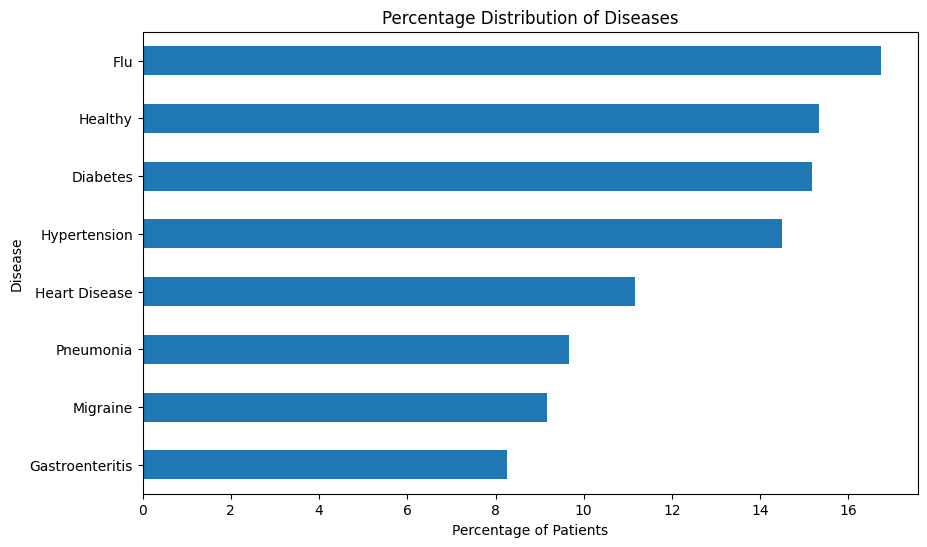

In [52]:
disease_percentage = df["Disease"].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))

disease_percentage.sort_values().plot(kind="barh")

plt.title("Percentage Distribution of Diseases")
plt.xlabel("Percentage of Patients")
plt.ylabel("Disease")

plt.show()

In [53]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 30, 45, 60, 75, 100],
    labels=["18-30", "31-45", "46-60", "61-75", "76+"]
)

In [54]:
df["Age_Group"].value_counts().sort_index()

Age_Group
18-30    513
31-45    917
46-60    994
61-75    447
76+      129
Name: count, dtype: int64

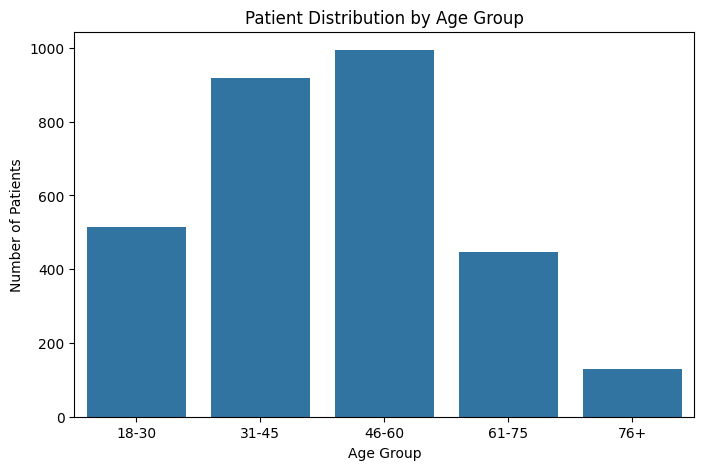

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Age_Group")

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

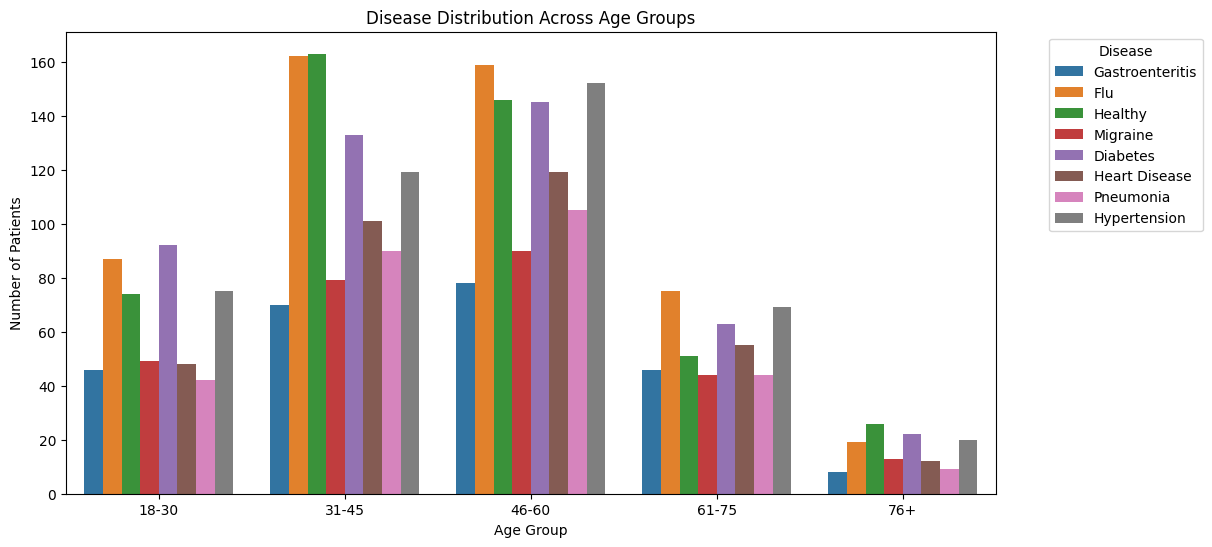

In [56]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Disease"
)

plt.title("Disease Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.legend(title="Disease", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [57]:
df.shape

(3000, 10)

In [58]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease,Age_Group
0,P100001,64.0,Female,"abdominal pain, nausea, vomiting",141.0,108.0,212.0,Unknown,Gastroenteritis,61-75
1,P100002,33.0,Male,"body ache, fever, fatigue",131.0,92.0,230.0,Seasonal flu,Flu,31-45
2,P100003,18.0,Male,Unknown,104.0,91.0,158.0,Unknown,Healthy,18-30
3,P100004,18.0,Female,"dizziness, nausea, sensitivity to light",112.0,85.0,206.0,Family history of migraine,Migraine,18-30
4,P100005,70.0,Male,"frequent urination, blurred vision, increased ...",157.0,188.0,184.0,Diabetes,Diabetes,61-75


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Patient_ID       3000 non-null   object  
 1   Age              3000 non-null   float64 
 2   Gender           3000 non-null   object  
 3   Symptoms         3000 non-null   object  
 4   Blood_Pressure   3000 non-null   float64 
 5   Sugar_Level      3000 non-null   float64 
 6   Cholesterol      3000 non-null   float64 
 7   Medical_History  3000 non-null   object  
 8   Disease          3000 non-null   object  
 9   Age_Group        3000 non-null   category
dtypes: category(1), float64(4), object(5)
memory usage: 237.5+ KB


In [60]:
df.to_csv("disease_prediction_cleaned_eda.csv", index=False)

In [61]:
disease_counts = df["Disease"].value_counts()

disease_counts

Disease
Flu                502
Healthy            460
Diabetes           455
Hypertension       435
Heart Disease      335
Pneumonia          290
Migraine           275
Gastroenteritis    248
Name: count, dtype: int64

In [62]:
disease_percentage = df["Disease"].value_counts(normalize=True) * 100

disease_percentage.round(2)

Disease
Flu                16.73
Healthy            15.33
Diabetes           15.17
Hypertension       14.50
Heart Disease      11.17
Pneumonia           9.67
Migraine            9.17
Gastroenteritis     8.27
Name: proportion, dtype: float64

In [63]:
df.groupby("Disease")[[
    "Age",
    "Blood_Pressure",
    "Sugar_Level",
    "Cholesterol"
]].mean().round(2)

,Age,Blood_Pressure,Sugar_Level,Cholesterol
Disease,,,,
Diabetes,45.84,132.13,173.83,227.24
Flu,45.87,119.97,101.84,190.78
Gastroenteritis,46.52,120.32,98.32,188.48
Healthy,46.13,116.73,93.28,178.15
Heart Disease,47.24,146.40,115.11,256.07
Hypertension,47.08,149.99,112.39,237.63
Migraine,46.97,124.88,100.09,198.08
Pneumonia,46.80,123.74,102.27,193.75


In [64]:
pd.crosstab(
    df["Disease"],
    df["Gender"],
    normalize="index"
).round(3) * 100

Gender,Female,Male
Disease,,
Diabetes,48.8,51.2
Flu,50.4,49.6
Gastroenteritis,49.2,50.8
Healthy,47.6,52.4
Heart Disease,50.1,49.9
Hypertension,49.0,51.0
Migraine,50.2,49.8
Pneumonia,45.2,54.8


In [65]:
df["Age_Group"].value_counts().sort_index()

Age_Group
18-30    513
31-45    917
46-60    994
61-75    447
76+      129
Name: count, dtype: int64

In [66]:
pd.crosstab(
    df["Age_Group"],
    df["Disease"]
)

Disease,Diabetes,Flu,Gastroenteritis,Healthy,Heart Disease,Hypertension,Migraine,Pneumonia
Age_Group,,,,,,,,
18-30,92,87,46,74,48,75,49,42
31-45,133,162,70,163,101,119,79,90
46-60,145,159,78,146,119,152,90,105
61-75,63,75,46,51,55,69,44,44
76+,22,19,8,26,12,20,13,9


In [67]:
correlation_matrix = df[[
    "Age",
    "Blood_Pressure",
    "Sugar_Level",
    "Cholesterol"
]].corr()

correlation_matrix.round(2)

,Age,Blood_Pressure,Sugar_Level,Cholesterol
Age,1.00,0.17,0.11,0.09
Blood_Pressure,0.17,1.00,0.18,0.49
Sugar_Level,0.11,0.18,1.00,0.30
Cholesterol,0.09,0.49,0.30,1.00


In [68]:
df.shape

(3000, 10)

In [69]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
Symptoms           0
Blood_Pressure     0
Sugar_Level        0
Cholesterol        0
Medical_History    0
Disease            0
Age_Group          0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df["Disease"].value_counts()

Disease
Flu                502
Healthy            460
Diabetes           455
Hypertension       435
Heart Disease      335
Pneumonia          290
Migraine           275
Gastroenteritis    248
Name: count, dtype: int64

In [72]:
df["Disease"].value_counts(normalize=True).mul(100).round(2)

Disease
Flu                16.73
Healthy            15.33
Diabetes           15.17
Hypertension       14.50
Heart Disease      11.17
Pneumonia           9.67
Migraine            9.17
Gastroenteritis     8.27
Name: proportion, dtype: float64

In [73]:
df.groupby("Disease")[[
    "Age",
    "Blood_Pressure",
    "Sugar_Level",
    "Cholesterol"
]].mean().round(2)

,Age,Blood_Pressure,Sugar_Level,Cholesterol
Disease,,,,
Diabetes,45.84,132.13,173.83,227.24
Flu,45.87,119.97,101.84,190.78
Gastroenteritis,46.52,120.32,98.32,188.48
Healthy,46.13,116.73,93.28,178.15
Heart Disease,47.24,146.40,115.11,256.07
Hypertension,47.08,149.99,112.39,237.63
Migraine,46.97,124.88,100.09,198.08
Pneumonia,46.80,123.74,102.27,193.75


In [74]:
pd.crosstab(
    df["Disease"],
    df["Gender"],
    normalize="index"
).mul(100).round(2)

Gender,Female,Male
Disease,,
Diabetes,48.79,51.21
Flu,50.40,49.60
Gastroenteritis,49.19,50.81
Healthy,47.61,52.39
Heart Disease,50.15,49.85
Hypertension,48.97,51.03
Migraine,50.18,49.82
Pneumonia,45.17,54.83
